In [6]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [7]:
def load_flo(filename):
    with open(filename, 'rb') as f:
        magic = np.fromfile(f, np.float32, count=1)
        if magic != 202021.25:
            raise ValueError('Format .flo invalide ou corrompu')

        width = np.fromfile(f, np.int32, count=1)[0]
        height = np.fromfile(f, np.int32, count=1)[0]
        data = np.fromfile(f, np.float32, count=2 * width * height)
        flow = np.resize(data, (height, width, 2))

    return flow

In [8]:
# Charger un fichier .flo
flow = load_flo("out.flo")


print("Taille de l'image :", flow.shape)  # (hauteur, largeur, 2)
print("Exemple de vecteur de mouvement :", flow[0, 0])  # Vecteur de mouvement à la position (0, 0)

Taille de l'image : (1528, 2560, 2)
Exemple de vecteur de mouvement : [-0.35324588 -0.17552763]


In [9]:
def flow_to_image(flow):
    h, w = flow.shape[:2]
    hsv = np.zeros((h, w, 3), dtype=np.uint8)

    # Calcul de la magnitude et de l'angle du mouvement
    mag, ang = cv2.cartToPolar(flow[..., 0], flow[..., 1])

    # Teinte (H) basée sur l'angle du mouvement
    hsv[..., 0] = ang * 180 / np.pi / 2
    # Saturation maximale
    hsv[..., 1] = 255
    # Valeur (V) basée sur l'intensité du mouvement (normalisée)
    hsv[..., 2] = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX)

    return cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)

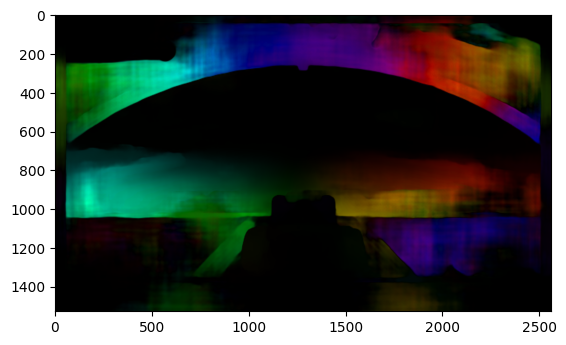

In [10]:
flow_image = flow_to_image(flow)

plt.imshow(cv2.cvtColor(flow_image, cv2.COLOR_BGR2RGB))